In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from Pipeline.Algorithm.ArtificialBeeColonyElmCV import ArtificialBeeColonyElmCV
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Methodology.EvaluationMatrix import EvaluationMatrix

In [2]:
gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_0()
gallstone_dataset.normal_data_split()

In [3]:
x_tr , x_val , y_tr , y_val = train_test_split(gallstone_dataset.x_train,
                                                gallstone_dataset.y_train,
                                                test_size= GlobalSetting.test_set_size,
                                                random_state=GlobalSetting.data_split_seed,
                                                stratify=gallstone_dataset.y_train)
scaler = MinMaxScaler()

In [4]:
abc_model = ArtificialBeeColonyElmCV(
        feature_size= x_tr.shape[1],
        hidden_size         = 30 ,
        activation_function = GlobalSetting.sigmoid,
        regularization_lambda= 2**-8,
        fitness_function    = GlobalSetting.evaluation_function,
        solution_size       = 50,
        trial_limit         = 40,
        max_iteration       = 100
    )
abc_model.init_random_state(42)
abc_model.employed_bee_apply_algo3()
abc_model.onlooker_bee_apply_algo2()
abc_model.apply_validation_dataset(x_val, y_val)
abc_model.fit(x_tr, y_tr)
val_fitness_curve = abc_model.val_fitness_curve
val_fitness_curve

Seed 42  | Iteration 100 complete | Duration: 0.2299s | Scout Triggers: 0 | Best Fitness: 0.832907 | Val Fitness: 0.746129

array([0.33710194, 0.64715023, 0.64715023, 0.53444024, 0.53444024,
       0.49777669, 0.49777669, 0.49777669, 0.49777669, 0.49777669,
       0.46130645, 0.46130645, 0.46130645, 0.41743932, 0.41743932,
       0.41743932, 0.41743932, 0.41743932, 0.41743932, 0.41743932,
       0.41743932, 0.41743932, 0.41743932, 0.41743932, 0.41743932,
       0.41306141, 0.41306141, 0.41306141, 0.41306141, 0.41306141,
       0.41306141, 0.37249241, 0.37249241, 0.41306141, 0.41306141,
       0.41306141, 0.41306141, 0.5301448 , 0.5301448 , 0.5301448 ,
       0.5301448 , 0.5301448 , 0.46130645, 0.46130645, 0.45474301,
       0.45474301, 0.45474301, 0.45474301, 0.45474301, 0.45474301,
       0.45474301, 0.45474301, 0.45474301, 0.45474301, 0.49225739,
       0.49225739, 0.49225739, 0.49225739, 0.49225739, 0.49225739,
       0.49225739, 0.49225739, 0.49225739, 0.49225739, 0.49225739,
       0.49225739, 0.49225739, 0.49225739, 0.49225739, 0.49225739,
       0.49225739, 0.49225739, 0.49225739, 0.49225739, 0.49225

In [5]:
best_fitness_curve = abc_model.convergence_curve
best_fitness_curve

array([0.48508816, 0.55448838, 0.55448838, 0.55773366, 0.55773366,
       0.56116578, 0.56116578, 0.56116578, 0.56116578, 0.56116578,
       0.56920123, 0.56920123, 0.56920123, 0.58060115, 0.58060115,
       0.58060115, 0.58060115, 0.58060115, 0.58060115, 0.58060115,
       0.58060115, 0.58060115, 0.58060115, 0.58060115, 0.58060115,
       0.59003938, 0.59003938, 0.59016156, 0.59016156, 0.59661528,
       0.59661528, 0.61155872, 0.61155872, 0.61372203, 0.61372203,
       0.61372203, 0.61372203, 0.62511887, 0.62511887, 0.62511887,
       0.62511887, 0.62511887, 0.62541649, 0.62541649, 0.65247966,
       0.65247966, 0.65247966, 0.65247966, 0.65247966, 0.65247966,
       0.65247966, 0.65247966, 0.65247966, 0.66346131, 0.66581489,
       0.66581489, 0.66581489, 0.66581489, 0.66581489, 0.66581489,
       0.66581489, 0.66581489, 0.66581489, 0.66581489, 0.66581489,
       0.66581489, 0.66581489, 0.66581489, 0.66581489, 0.66581489,
       0.66581489, 0.66581489, 0.66581489, 0.66581489, 0.66581

In [6]:
y_pred = abc_model.predict(x_test = gallstone_dataset.x_test)
evaluation_result = EvaluationMatrix(y_true = gallstone_dataset.y_test, y_pred=y_pred)
evaluation_result.get_all_metrics()

{'Accuracy': np.float64(0.765625),
 'Precision': 0.7741935483870968,
 'Recall': 0.75,
 'NPV': 0.7575757575757576,
 'Specificity': 0.78125,
 'F1-Score': 0.7619047619047619,
 'F2-Score': 0.7547169811320755,
 'Bal Accuracy': 0.765625,
 'MCC': 0.531509589558614}

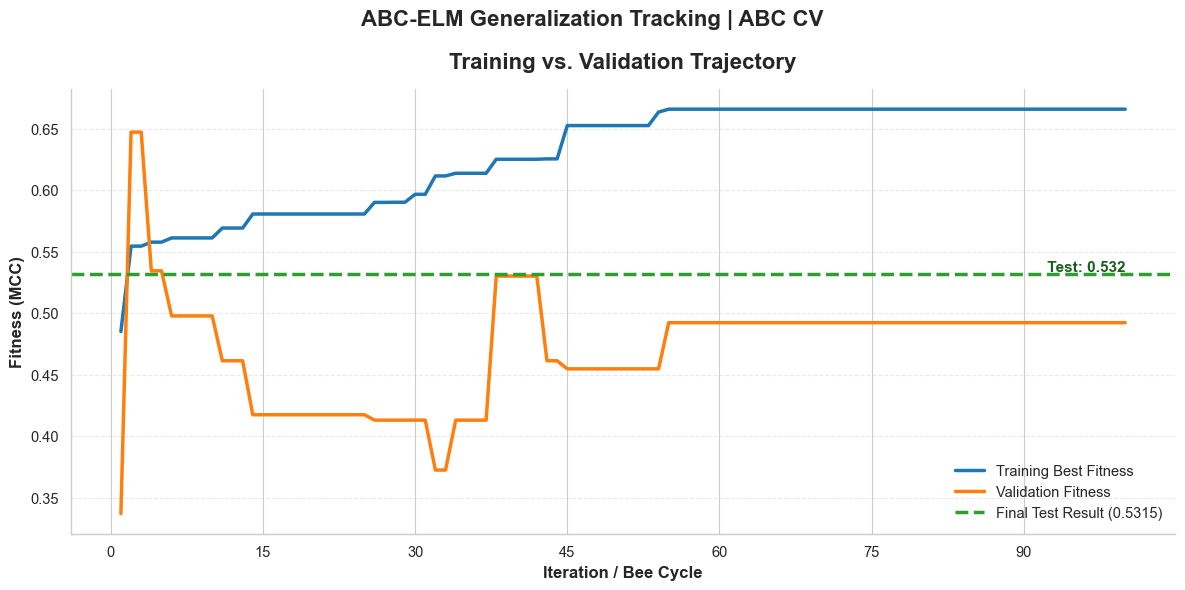

In [8]:
from Pipeline.Global.Plotting import Plotting

metric_to_track = GlobalSetting.evaluation_function
final_test_score = evaluation_result.get_all_metrics()[metric_to_track]

# 2. Call the new plotting method
Plotting.plot_train_val_curve(
    convergence_curve=abc_model.convergence_curve,
    val_fitness_curve=abc_model.val_fitness_curve,
    experiment_name="ABC CV",
    final_test_result=final_test_score,
    fitness_metric=metric_to_track,
    is_final_record=False # Set to True to save the PNG
)